In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from tqdm import tqdm
import seaborn as sns

from rdkit.Chem import Descriptors
from collections import Counter
from rdkit.Chem import BondType
from rdkit.Chem import Lipinski, rdMolDescriptors

from rdkit.Chem.Scaffolds import MurckoScaffold
from ogb.lsc import PygPCQM4Mv2Dataset
from torch_geometric.data import Data





c:\Users\js731\Downloads\GNN-HOMO-LUMO\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = torch.load(r"C:\Users\js731\Downloads\GNN-HOMO-LUMO\dataset\final_dataset_with_targets.pt")

print(len(data))
print(data[0])

3746620
{'smiles': 'O=C1[N]c2ccncc2[CH][C@@H]1c1ccc(cc1)C', 'num_atoms': 18, 'num_bonds': 20, 'target': 3.0476751256}


In [4]:
df = pd.DataFrame(data)

print(df.head())
print(df.info())

                                  smiles  num_atoms  num_bonds    target
0  O=C1[N]c2ccncc2[CH][C@@H]1c1ccc(cc1)C         18         20  3.047675
1          COc1cc(OC)ccc1/C=C/N(C(=O)C)C         17         17  4.454504
2            C=CCN(C(=O)C)/C=C/c1ccccc1C         16         16  4.693964
3            C=CCN(C(=O)C)/C=C/c1ccccc1F         16         16  4.552465
4           C=CCN(C(=O)C)/C=C/c1ccccc1Cl         16         16  4.620493
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3746620 entries, 0 to 3746619
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   smiles     object 
 1   num_atoms  int64  
 2   num_bonds  int64  
 3   target     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 114.3+ MB
None


In [5]:
# Extract targets and check for missing values
targets = [d.get('target') for d in data]

# Count None/NaN values
none_count = sum(1 for t in targets if t is None or (isinstance(t, float) and np.isnan(t)))

print(f"Total samples: {len(targets)}")
print(f"Samples with valid targets: {len(targets) - none_count}")
print(f"Samples with None/NaN targets: {none_count}")

# Filter to clean data only
clean_data = [d for d in data if d.get('target') is not None and not pd.isna(d.get('target'))]
print(f"Clean samples for training: {len(clean_data)}")

# Optional: Create DataFrame from clean data for easier analysis
df_clean = pd.DataFrame(clean_data)
print(f"\nNull counts in clean DataFrame:")
print(df_clean.isnull().sum())

Total samples: 3746620
Samples with valid targets: 3426385
Samples with None/NaN targets: 320235
Clean samples for training: 3426385

Null counts in clean DataFrame:
smiles       0
num_atoms    0
num_bonds    0
target       0
dtype: int64


In [6]:
# Sample for faster testing (use full data for final check)
sample_size = min(10000, len(clean_data))
sample_data = clean_data[:sample_size]

valid_count = 0
invalid_smiles = []

for item in tqdm(sample_data, desc="Validating SMILES"):
    mol = Chem.MolFromSmiles(item['smiles'])
    if mol is not None:
        valid_count += 1
    else:
        invalid_smiles.append(item['smiles'])

valid_rate = valid_count / sample_size * 100
print(f"\n SMILES Validation Results:")
print(f"  Valid: {valid_count}/{sample_size} ({valid_rate:.2f}%)")
print(f"  Invalid: {len(invalid_smiles)}/{sample_size}")

# Show first few invalid SMILES if any
if invalid_smiles:
    print(f"\n First 5 invalid SMILES:")
    for i, smi in enumerate(invalid_smiles[:5]):
        print(f"  {i+1}: {smi}")

Validating SMILES: 100%|██████████| 10000/10000 [00:00<00:00, 10970.47it/s]


 SMILES Validation Results:
  Valid: 10000/10000 (100.00%)
  Invalid: 0/10000



 Target Statistics:
  Min: 0.3755 eV
  Max: 47.0240 eV
  Mean: 5.6816 eV
  Std: 1.1615 eV
  Median: 5.5783 eV


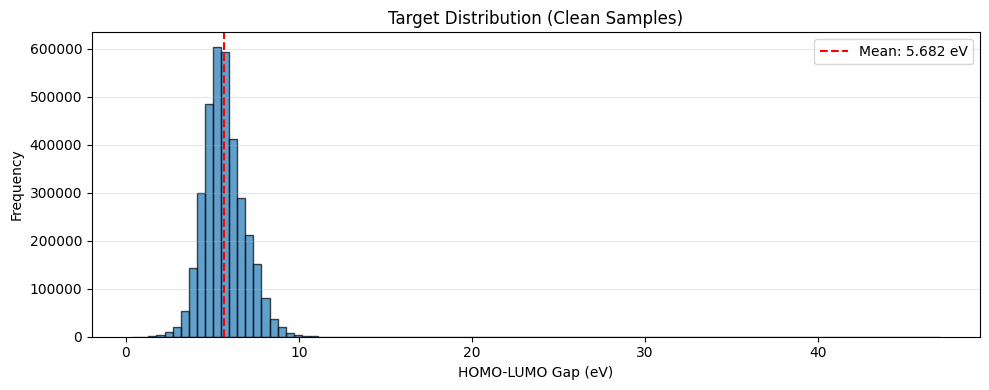

In [7]:
# Extract targets from clean data
targets = [d['target'] for d in clean_data]

print(f"\n Target Statistics:")
print(f"  Min: {min(targets):.4f} eV")
print(f"  Max: {max(targets):.4f} eV")
print(f"  Mean: {np.mean(targets):.4f} eV")
print(f"  Std: {np.std(targets):.4f} eV")
print(f"  Median: {np.median(targets):.4f} eV")

# Plot histogram
plt.figure(figsize=(10, 4))
plt.hist(targets, bins=100, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(targets), color='red', linestyle='--', label=f"Mean: {np.mean(targets):.3f} eV")
plt.xlabel("HOMO-LUMO Gap (eV)")
plt.ylabel("Frequency")
plt.title("Target Distribution (Clean Samples)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Load your clean data
data = torch.load(r"C:\Users\js731\Downloads\GNN-HOMO-LUMO\dataset\final_dataset_with_targets.pt")

# Filter to only valid targets
clean_data = [d for d in data if d.get('target') is not None]

# Convert to DataFrame
df = pd.DataFrame(clean_data)

print(f"Total samples: {len(df)}")
print(f"Target range: {df['target'].min():.4f} - {df['target'].max():.4f} eV")

# Find outliers (> 10 eV)
outliers = df[df['target'] > 10].sort_values('target', ascending=False)
print(f"\nSamples with target > 10 eV: {len(outliers)}")
print(f"\nTop 10 highest gaps:")
print(outliers.head(10))

# Investigate the maximum
max_sample = outliers.iloc[0]
print(f"\n MAXIMUM OUTLAYER DETAILS:")
print(f"  SMILES: {max_sample['smiles']}")
print(f"  Num atoms: {max_sample['num_atoms']}")
print(f"  Num bonds: {max_sample['num_bonds']}")
print(f"  Target: {max_sample['target']:.4f} eV")

# Try to parse with RDKit
mol = Chem.MolFromSmiles(max_sample['smiles'])
if mol:
    print(f"\n  RDKit Info:")
    print(f"    - Valid molecule: Yes")
    print(f"    - Num heavy atoms: {mol.GetNumHeavyAtoms()}")
    print(f"    - Num bonds: {mol.GetNumBonds()}")
    
    # Check atom types
    atom_types = [atom.GetSymbol() for atom in mol.GetAtoms()]
    print(f"    - Atom types: {set(atom_types)}")
else:
    print(f"\n  RDKit Info: Invalid SMILES!")

Total samples: 3746620
Target range: 0.3755 - 47.0240 eV

Samples with target > 10 eV: 2508

Top 10 highest gaps:
                                 smiles  num_atoms  num_bonds     target
2650108                       [He].[He]          2          0  47.023995
2687974                  [He].[He].[He]          3          0  46.381806
2484463                  [Ar].[Ar].[Ar]          3          0  21.831694
3161802               FC(OC(F)(F)F)(F)F          9          8  13.970325
2409453        FC1(F)OC(F)(F)OC(O1)(F)F         12         12  13.325415
2391620       FC(OC(F)(F)F)(OC(F)(F)F)F         13         12  13.243781
3607491                FC(C(F)(F)F)(F)F          8          7  12.704996
2260415               CC(OC(F)(F)F)(F)F          9          8  12.685948
2599817  CC(C(F)(F)F)(C(F)(F)F)C(F)(F)F         14         13  12.661457
3169671             FC(OC(OC(F)F)(F)F)F         11         10  12.582544

 MAXIMUM OUTLAYER DETAILS:
  SMILES: [He].[He]
  Num atoms: 2
  Num bonds: 0
  Tar

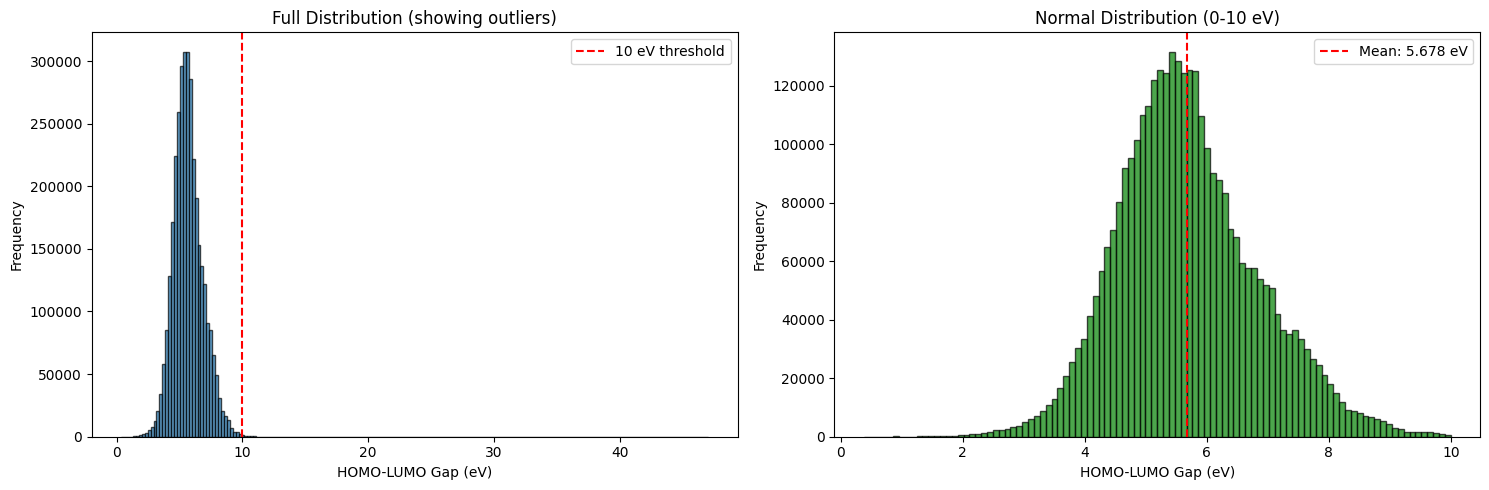


 STATISTICS:
  All data:
    Mean: 5.6816 eV
    Std: 1.1615 eV
    Min: 0.3755 eV
    Max: 47.0240 eV

  Filtered data (target ≤ 10 eV):
    Count: 3423877 / 3746620 (91.39%)
    Mean: 5.6780 eV
    Std: 1.1541 eV
    Min: 0.3755 eV
    Max: 9.9975 eV


In [9]:
# Plot full distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(df['target'], bins=200, edgecolor='black', alpha=0.7)
plt.xlabel('HOMO-LUMO Gap (eV)')
plt.ylabel('Frequency')
plt.title('Full Distribution (showing outliers)')
plt.axvline(x=10, color='red', linestyle='--', label='10 eV threshold')
plt.legend()

plt.subplot(1, 2, 2)
# Plot only reasonable range
df_normal = df[df['target'] <= 10]
plt.hist(df_normal['target'], bins=100, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('HOMO-LUMO Gap (eV)')
plt.ylabel('Frequency')
plt.title('Normal Distribution (0-10 eV)')
plt.axvline(x=df_normal['target'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_normal['target'].mean():.3f} eV")
plt.legend()

plt.tight_layout()
plt.show()

# Statistics
print(f"\n STATISTICS:")
print(f"  All data:")
print(f"    Mean: {df['target'].mean():.4f} eV")
print(f"    Std: {df['target'].std():.4f} eV")
print(f"    Min: {df['target'].min():.4f} eV")
print(f"    Max: {df['target'].max():.4f} eV")

print(f"\n  Filtered data (target ≤ 10 eV):")
print(f"    Count: {len(df_normal)} / {len(df)} ({len(df_normal)/len(df)*100:.2f}%)")
print(f"    Mean: {df_normal['target'].mean():.4f} eV")
print(f"    Std: {df_normal['target'].std():.4f} eV")
print(f"    Min: {df_normal['target'].min():.4f} eV")
print(f"    Max: {df_normal['target'].max():.4f} eV")

In [10]:
# Check if outliers have common characteristics
print("Outlier analysis:")
print(f"  Average num_atoms in outliers: {outliers['num_atoms'].mean():.2f}")
print(f"  Average num_atoms in normal: {df_normal['num_atoms'].mean():.2f}")

# Check SMILES patterns
print(f"\n  Sample outlier SMILES:")
for idx, row in outliers.head(5).iterrows():
    print(f"    {row['smiles'][:50]}... (gap={row['target']:.2f} eV)")

Outlier analysis:
  Average num_atoms in outliers: 10.30
  Average num_atoms in normal: 14.15

  Sample outlier SMILES:
    [He].[He]... (gap=47.02 eV)
    [He].[He].[He]... (gap=46.38 eV)
    [Ar].[Ar].[Ar]... (gap=21.83 eV)
    FC(OC(F)(F)F)(F)F... (gap=13.97 eV)
    FC1(F)OC(F)(F)OC(O1)(F)F... (gap=13.33 eV)


 OUTLIER DETECTION ANALYSIS

 Method 1: Fixed Threshold
  Samples with target > 10 eV: 2508 (0.067%)
  Samples with target > 15 eV: 3 (0.000%)
  Samples with target > 20 eV: 3 (0.000%)

 Method 2: IQR Method
  Q1: 4.9035 eV
  Q3: 6.3647 eV
  IQR: 1.4613 eV
  Normal range: [2.7116, 8.5566] eV
  Outliers (1.5*IQR): 61234 (1.634%)
  Extreme outliers (3*IQR): 558 (0.015%)

 Method 3: Standard Deviation Method
  Mean: 5.6816 eV
  Std: 1.1615 eV
  Range (±2σ): [3.3586, 8.0046] eV
  Outliers (±2σ): 162561 (4.339%)
  Range (±3σ): [2.1971, 9.1661] eV
  Outliers (±3σ): 18505 (0.494%)
 EXTREME OUTLIER ANALYSIS (> 10 eV)

Total extreme outliers: 2508

Noble gas molecules: 1300

Top 10 extreme outliers:
                                 smiles  num_atoms  num_bonds     target
2650108                       [He].[He]          2          0  47.023995
2687974                  [He].[He].[He]          3          0  46.381806
2484463                  [Ar].[Ar].[Ar]          3          0  21.831694
3161802 

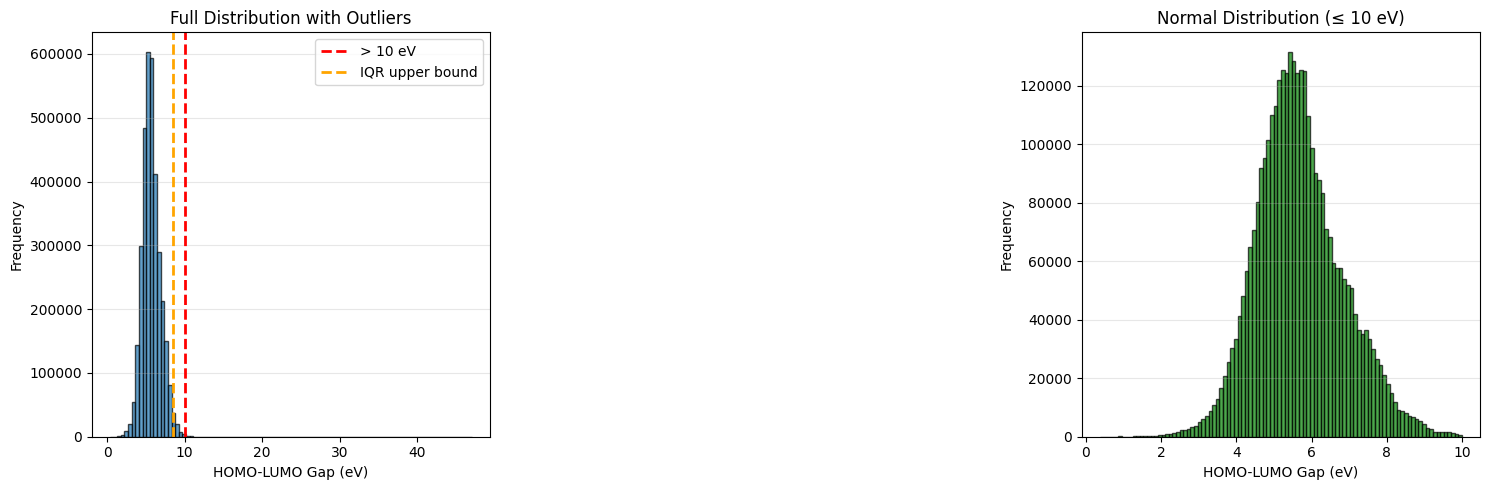

 SUMMARY
Total samples: 3746620
Samples with target ≤ 10 eV: 3744112 (99.933%)
Samples with target > 10 eV: 2508 (0.067%)


In [11]:
# Convert to DataFrame if not already
df_clean = pd.DataFrame([d for d in data if d.get('target') is not None])

# Extract targets
targets = df_clean['target'].values


print(" OUTLIER DETECTION ANALYSIS")


# Method 1: Simple threshold (> 10 eV)
threshold_10 = len(df_clean[df_clean['target'] > 10])
threshold_15 = len(df_clean[df_clean['target'] > 15])
threshold_20 = len(df_clean[df_clean['target'] > 20])

print(f"\n Method 1: Fixed Threshold")
print(f"  Samples with target > 10 eV: {threshold_10} ({threshold_10/len(df_clean)*100:.3f}%)")
print(f"  Samples with target > 15 eV: {threshold_15} ({threshold_15/len(df_clean)*100:.3f}%)")
print(f"  Samples with target > 20 eV: {threshold_20} ({threshold_20/len(df_clean)*100:.3f}%)")

# Method 2: IQR (Interquartile Range) Method
Q1 = df_clean['target'].quantile(0.25)
Q3 = df_clean['target'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
upper_bound_extreme = Q3 + 3.0 * IQR

outliers_iqr = len(df_clean[(df_clean['target'] < lower_bound) | (df_clean['target'] > upper_bound)])
outliers_extreme = len(df_clean[df_clean['target'] > upper_bound_extreme])

print(f"\n Method 2: IQR Method")
print(f"  Q1: {Q1:.4f} eV")
print(f"  Q3: {Q3:.4f} eV")
print(f"  IQR: {IQR:.4f} eV")
print(f"  Normal range: [{lower_bound:.4f}, {upper_bound:.4f}] eV")
print(f"  Outliers (1.5*IQR): {outliers_iqr} ({outliers_iqr/len(df_clean)*100:.3f}%)")
print(f"  Extreme outliers (3*IQR): {outliers_extreme} ({outliers_extreme/len(df_clean)*100:.3f}%)")

# Method 3: Standard Deviation Method
mean_target = df_clean['target'].mean()
std_target = df_clean['target'].std()

outliers_2std = len(df_clean[(df_clean['target'] < mean_target - 2*std_target) | 
                            (df_clean['target'] > mean_target + 2*std_target)])
outliers_3std = len(df_clean[(df_clean['target'] < mean_target - 3*std_target) | 
                            (df_clean['target'] > mean_target + 3*std_target)])

print(f"\n Method 3: Standard Deviation Method")
print(f"  Mean: {mean_target:.4f} eV")
print(f"  Std: {std_target:.4f} eV")
print(f"  Range (±2σ): [{mean_target - 2*std_target:.4f}, {mean_target + 2*std_target:.4f}] eV")
print(f"  Outliers (±2σ): {outliers_2std} ({outliers_2std/len(df_clean)*100:.3f}%)")
print(f"  Range (±3σ): [{mean_target - 3*std_target:.4f}, {mean_target + 3*std_target:.4f}] eV")
print(f"  Outliers (±3σ): {outliers_3std} ({outliers_3std/len(df_clean)*100:.3f}%)")

# Analyze the extreme outliers

print(" EXTREME OUTLIER ANALYSIS (> 10 eV)")


extreme_outliers = df_clean[df_clean['target'] > 10].sort_values('target', ascending=False)
print(f"\nTotal extreme outliers: {len(extreme_outliers)}")

# Check for noble gases or invalid structures
noble_gas_patterns = ['[He]', '[Ne]', '[Ar]', '[Kr]', '[Xe]', '[Rn]']
noble_gas_outliers = extreme_outliers[extreme_outliers['smiles'].str.contains('|'.join(noble_gas_patterns), regex=True)]

print(f"\nNoble gas molecules: {len(noble_gas_outliers)}")
print(f"\nTop 10 extreme outliers:")
print(extreme_outliers.head(10)[['smiles', 'num_atoms', 'num_bonds', 'target']])

# Check for molecules with 0 bonds
zero_bond_outliers = extreme_outliers[extreme_outliers['num_bonds'] == 0]
print(f"\n  Molecules with 0 bonds: {len(zero_bond_outliers)}")
if len(zero_bond_outliers) > 0:
    print("These are likely invalid/disconnected structures!")
    print(zero_bond_outliers.head(5)[['smiles', 'num_atoms', 'target']])

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(targets, bins=100, edgecolor='black', alpha=0.7)
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='> 10 eV')
plt.axvline(x=upper_bound, color='orange', linestyle='--', linewidth=2, label='IQR upper bound')
plt.xlabel('HOMO-LUMO Gap (eV)')
plt.ylabel('Frequency')
plt.title('Full Distribution with Outliers')
plt.legend()
plt.grid(axis='y', alpha=0.3)



plt.subplot(1, 3, 3)
normal_data = df_clean[df_clean['target'] <= 10]
plt.hist(normal_data['target'], bins=100, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('HOMO-LUMO Gap (eV)')
plt.ylabel('Frequency')
plt.title('Normal Distribution (≤ 10 eV)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary

print(" SUMMARY")

print(f"Total samples: {len(df_clean)}")
print(f"Samples with target ≤ 10 eV: {len(df_clean) - threshold_10} ({(len(df_clean) - threshold_10)/len(df_clean)*100:.3f}%)")
print(f"Samples with target > 10 eV: {threshold_10} ({threshold_10/len(df_clean)*100:.3f}%)")


In [12]:
# Filter out extreme outliers
df_clean = df[df['target'] <= 10].copy()
print(f"Removed {len(df) - len(df_clean)} outliers")
print(f"Remaining samples: {len(df_clean)}")

# Save clean dataset
clean_data_list = df_clean.to_dict('records')
torch.save(clean_data_list, r"C:\Users\js731\Downloads\GNN-HOMO-LUMO\dataset\final_dataset_clean.pt")

Removed 322743 outliers
Remaining samples: 3423877


[22:30:03] Explicit valence for atom # 1 Si, 5, is greater than permitted


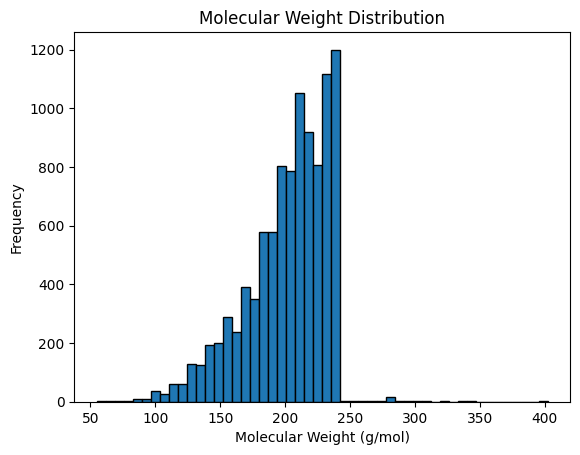

MW range: 55.08 - 402.45 g/mol
Mean MW: 202.13 g/mol


In [13]:
# Sample for speed
sample_mols = df_clean['smiles'].sample(10000).tolist()

# Extract molecular weights
mol_weights = []
for smi in sample_mols:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol_weights.append(Descriptors.MolWt(mol))

plt.hist(mol_weights, bins=50, edgecolor='black')
plt.xlabel('Molecular Weight (g/mol)')
plt.ylabel('Frequency')
plt.title('Molecular Weight Distribution')
plt.show()

print(f"MW range: {min(mol_weights):.2f} - {max(mol_weights):.2f} g/mol")
print(f"Mean MW: {sum(mol_weights)/len(mol_weights):.2f} g/mol")

           num_atoms  num_bonds    target
num_atoms   1.000000   0.969295 -0.255034
num_bonds   0.969295   1.000000 -0.307695
target     -0.255034  -0.307695  1.000000


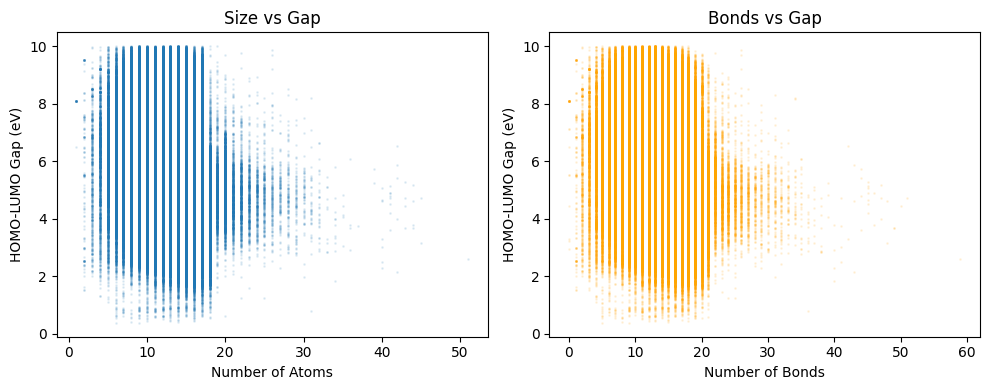

In [14]:
# Check if molecular size correlates with HOMO-LUMO gap
print(df_clean[['num_atoms', 'num_bonds', 'target']].corr())

# 
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(df_clean['num_atoms'], df_clean['target'], alpha=0.1, s=1)
plt.xlabel('Number of Atoms')
plt.ylabel('HOMO-LUMO Gap (eV)')
plt.title('Size vs Gap')

plt.subplot(1, 2, 2)
plt.scatter(df_clean['num_bonds'], df_clean['target'], alpha=0.1, s=1, color='orange')
plt.xlabel('Number of Bonds')
plt.ylabel('HOMO-LUMO Gap (eV)')
plt.title('Bonds vs Gap')
plt.tight_layout()
plt.show()

In [15]:
# Extract targets and check for missing values
targets = [d.get('target') for d in data]

# Count None/NaN values
none_count = sum(1 for t in targets if t is None or (isinstance(t, float) and np.isnan(t)))

print(f"Total samples: {len(targets)}")
print(f"Samples with valid targets: {len(targets) - none_count}")
print(f"Samples with None/NaN targets: {none_count}")

#  Filter to clean data only
clean_data = [d for d in data if d.get('target') is not None and not pd.isna(d.get('target'))]
print(f" Clean samples for training: {len(clean_data)}")

# Optional: Create DataFrame from clean data for easier analysis
df_clean = pd.DataFrame(clean_data)
print(f"\nNull counts in clean DataFrame:")
print(df_clean.isnull().sum())

Total samples: 3746620
Samples with valid targets: 3426385
Samples with None/NaN targets: 320235
 Clean samples for training: 3426385

Null counts in clean DataFrame:
smiles       0
num_atoms    0
num_bonds    0
target       0
dtype: int64


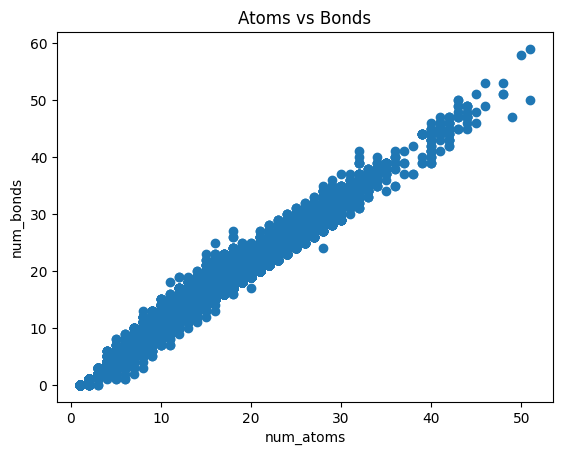

In [16]:
plt.scatter(df["num_atoms"], df["num_bonds"])
plt.xlabel("num_atoms")
plt.ylabel("num_bonds")
plt.title("Atoms vs Bonds")
plt.show()

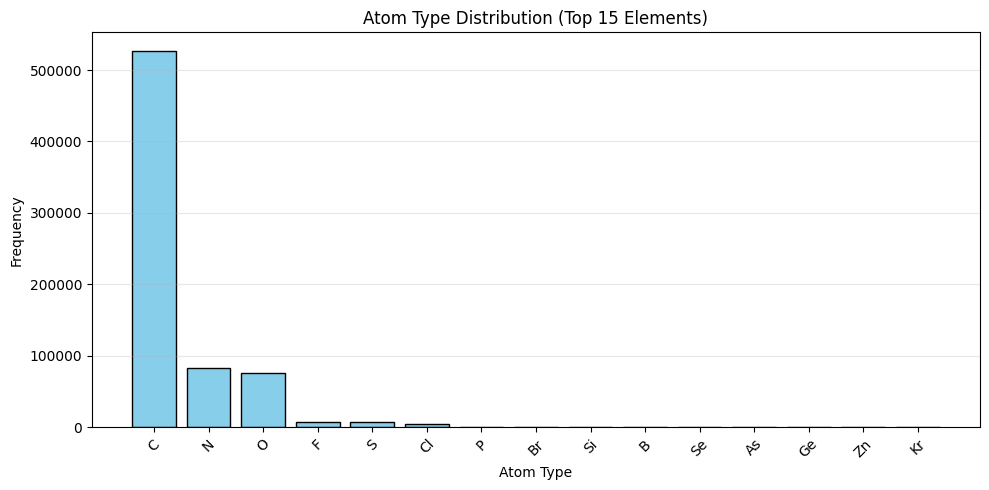

 Top 10 Atom Types:
  C: 526,486 (74.46%)
  N: 82,548 (11.68%)
  O: 75,471 (10.67%)
  F: 7,912 (1.12%)
  S: 7,674 (1.09%)
  Cl: 4,907 (0.69%)
  P: 634 (0.09%)
  Br: 572 (0.08%)
  Si: 511 (0.07%)
  B: 270 (0.04%)


In [17]:
# Sample for faster analysis (use full data for final report)
sample_size = min(50000, len(df))
sample_smiles = df['smiles'].sample(sample_size, random_state=42).tolist()

# Count atom types
atom_counter = Counter()

for smi in sample_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for atom in mol.GetAtoms():
            atom_counter[atom.GetSymbol()] += 1

# Plot atom distribution
plt.figure(figsize=(10, 5))
atoms, counts = zip(*atom_counter.most_common(15))  # Top 15 elements
plt.bar(atoms, counts, color='skyblue', edgecolor='black')
plt.xlabel('Atom Type')
plt.ylabel('Frequency')
plt.title('Atom Type Distribution (Top 15 Elements)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(" Top 10 Atom Types:")
for atom, count in atom_counter.most_common(10):
    pct = count / sum(atom_counter.values()) * 100
    print(f"  {atom}: {count:,} ({pct:.2f}%)")

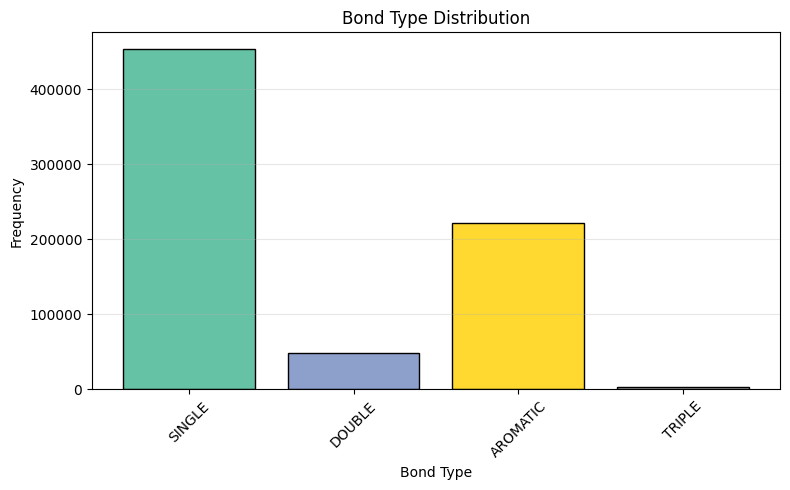


 Bond Type Distribution:
  SINGLE: 453,351 (62.26%)
  AROMATIC: 222,518 (30.56%)
  DOUBLE: 48,374 (6.64%)
  TRIPLE: 3,928 (0.54%)


In [18]:
# Count bond types
bond_counter = Counter()

for smi in sample_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for bond in mol.GetBonds():
            bond_type = bond.GetBondType()
            bond_counter[str(bond_type)] += 1

# Plot bond distribution
plt.figure(figsize=(8, 5))
bond_types, counts = zip(*bond_counter.items())
colors = plt.cm.Set2(np.linspace(0, 1, len(bond_types)))
plt.bar(bond_types, counts, color=colors, edgecolor='black')
plt.xlabel('Bond Type')
plt.ylabel('Frequency')
plt.title('Bond Type Distribution')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print("\n Bond Type Distribution:")
total_bonds = sum(bond_counter.values())
for bond_type, count in bond_counter.most_common():
    pct = count / total_bonds * 100
    print(f"  {bond_type}: {count:,} ({pct:.2f}%)")


 Processed 50000/50000 valid molecules


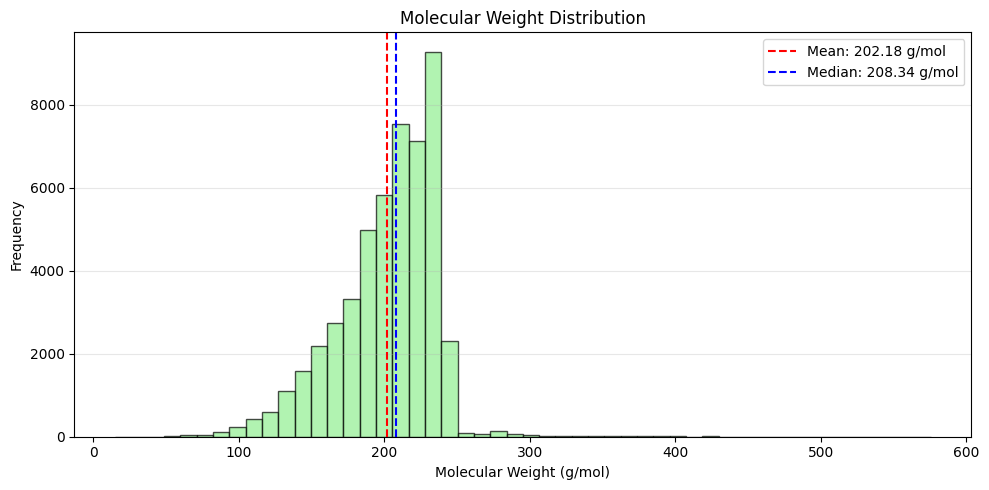


 Molecular Weight Statistics:
  Min: 15.02 g/mol
  Max: 575.58 g/mol
  Mean: 202.18 g/mol
  Std: 34.10 g/mol
  Q1 (25%): 183.25 g/mol
  Q3 (75%): 226.19 g/mol


In [19]:
# Calculate molecular weights
mol_weights = []
valid_count = 0

for smi in sample_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mw = Descriptors.MolWt(mol)
        mol_weights.append(mw)
        valid_count += 1

print(f"\n Processed {valid_count}/{len(sample_smiles)} valid molecules")

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(mol_weights, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
plt.axvline(np.mean(mol_weights), color='red', linestyle='--', 
            label=f"Mean: {np.mean(mol_weights):.2f} g/mol")
plt.axvline(np.median(mol_weights), color='blue', linestyle='--', 
            label=f"Median: {np.median(mol_weights):.2f} g/mol")
plt.xlabel('Molecular Weight (g/mol)')
plt.ylabel('Frequency')
plt.title('Molecular Weight Distribution')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Statistics
print(f"\n Molecular Weight Statistics:")
print(f"  Min: {min(mol_weights):.2f} g/mol")
print(f"  Max: {max(mol_weights):.2f} g/mol")
print(f"  Mean: {np.mean(mol_weights):.2f} g/mol")
print(f"  Std: {np.std(mol_weights):.2f} g/mol")
print(f"  Q1 (25%): {np.percentile(mol_weights, 25):.2f} g/mol")
print(f"  Q3 (75%): {np.percentile(mol_weights, 75):.2f} g/mol")

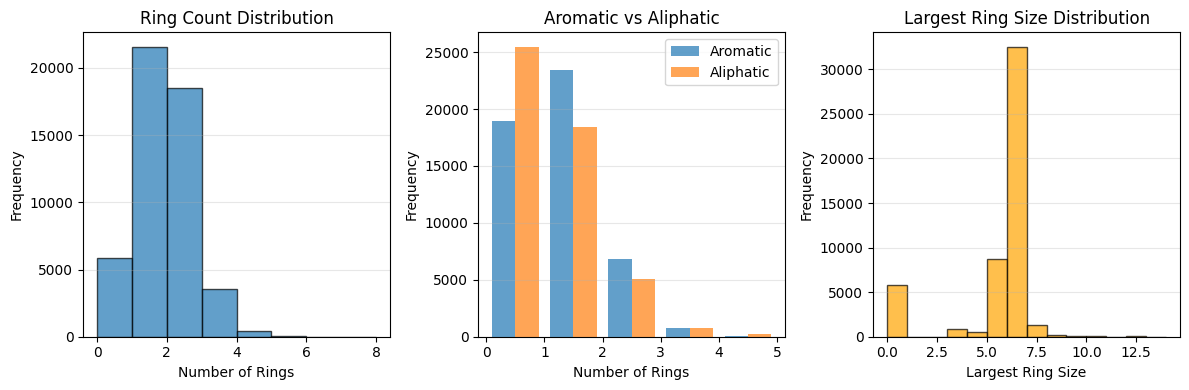


 Ring/Aromaticity Statistics:
  Molecules with rings: 44174/50000
  Molecules with aromatic rings: 31030/50000 (62.06%)
  Avg rings per molecule: 1.43
  Avg aromatic rings: 0.79
  Avg largest ring size: 5.10


In [20]:


# Initialize counters
ring_stats = {
    'num_rings': [],
    'num_aromatic_rings': [],
    'num_aliphatic_rings': [],
    'largest_ring_size': [],
    'is_aromatic': []
}

for smi in sample_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        #  Ring counts
        ring_info = mol.GetRingInfo()
        ring_stats['num_rings'].append(ring_info.NumRings())
        ring_stats['num_aromatic_rings'].append(Lipinski.NumAromaticRings(mol))
        ring_stats['num_aliphatic_rings'].append(Lipinski.NumAliphaticRings(mol))
        
        # Largest ring size
        if ring_info.NumRings() > 0:
            largest = max(len(r) for r in ring_info.AtomRings())
            ring_stats['largest_ring_size'].append(largest)
        else:
            ring_stats['largest_ring_size'].append(0)
        
        #  Aromaticity flag - FIXED!
        # Check if molecule has any aromatic rings
        ring_stats['is_aromatic'].append(Lipinski.NumAromaticRings(mol) > 0)

# Plot: Number of rings
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(ring_stats['num_rings'], bins=range(0, max(ring_stats['num_rings'])+2), 
        edgecolor='black', alpha=0.7)
plt.xlabel('Number of Rings')
plt.ylabel('Frequency')
plt.title('Ring Count Distribution')
plt.grid(axis='y', alpha=0.3)

# Plot: Aromatic vs Aliphatic rings
plt.subplot(1, 3, 2)
plt.hist([ring_stats['num_aromatic_rings'], ring_stats['num_aliphatic_rings']], 
        bins=range(0, 6), label=['Aromatic', 'Aliphatic'], alpha=0.7)
plt.xlabel('Number of Rings')
plt.ylabel('Frequency')
plt.title('Aromatic vs Aliphatic')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Plot: Largest ring size
plt.subplot(1, 3, 3)
plt.hist(ring_stats['largest_ring_size'], bins=range(0, 15), 
        edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Largest Ring Size')
plt.ylabel('Frequency')
plt.title('Largest Ring Size Distribution')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n Ring/Aromaticity Statistics:")
print(f"  Molecules with rings: {sum(1 for r in ring_stats['num_rings'] if r > 0)}/{len(ring_stats['num_rings'])}")
print(f"  Molecules with aromatic rings: {sum(ring_stats['is_aromatic'])}/{len(ring_stats['is_aromatic'])} ({sum(ring_stats['is_aromatic'])/len(ring_stats['is_aromatic'])*100:.2f}%)")
print(f"  Avg rings per molecule: {np.mean(ring_stats['num_rings']):.2f}")
print(f"  Avg aromatic rings: {np.mean(ring_stats['num_aromatic_rings']):.2f}")
print(f"  Avg largest ring size: {np.mean(ring_stats['largest_ring_size']):.2f}")


 Correlation with HOMO-LUMO Gap:
target                1.000000
mol_weight           -0.226006
num_atoms            -0.258059
num_bonds            -0.308594
num_rings            -0.318538
num_aromatic_rings   -0.520491
Name: target, dtype: float64


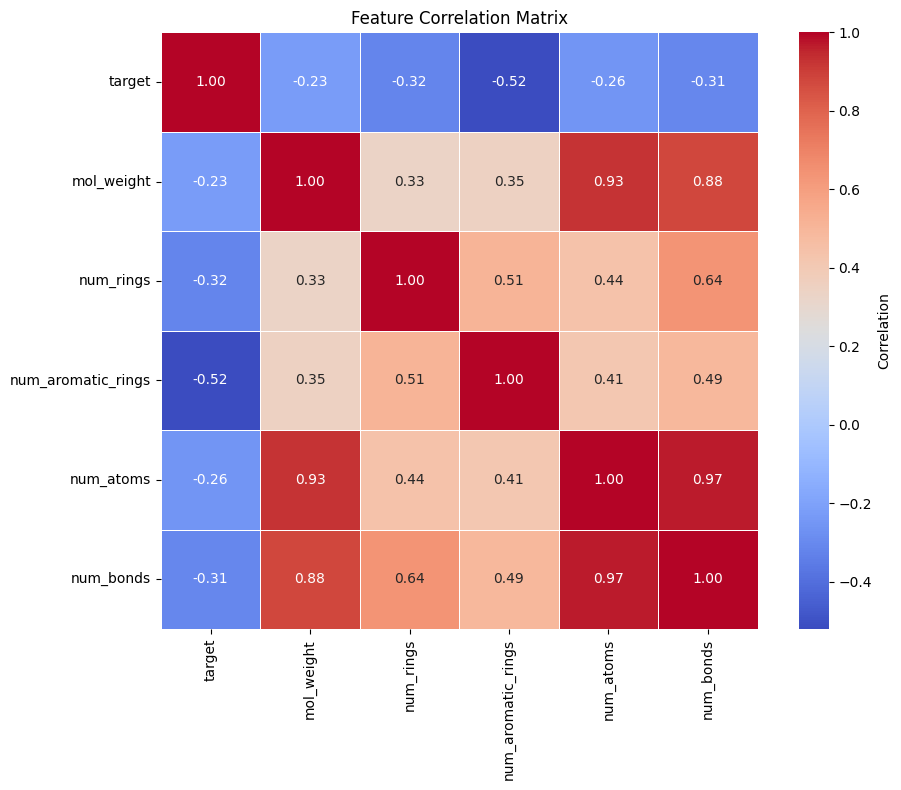

In [21]:
# Sample for faster analysis
sample_size = min(50000, len(df))
sample_df = df.sample(sample_size, random_state=42).copy()

# Extract chemical features
mol_weights = []
num_rings = []
num_aromatic_rings = []

for smi in sample_df['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol_weights.append(Descriptors.MolWt(mol))
        #  FIXED: Use rdMolDescriptors instead of Lipinski
        num_rings.append(rdMolDescriptors.CalcNumRings(mol))  
        num_aromatic_rings.append(Lipinski.NumAromaticRings(mol))  # This one exists ✓
    else:
        mol_weights.append(np.nan)
        num_rings.append(np.nan)
        num_aromatic_rings.append(np.nan)

# Create feature DataFrame
feature_df = pd.DataFrame({
    'target': sample_df['target'],
    'mol_weight': mol_weights,
    'num_rings': num_rings,
    'num_aromatic_rings': num_aromatic_rings,
    'num_atoms': sample_df['num_atoms'],
    'num_bonds': sample_df['num_bonds']
}).dropna()

# Correlation analysis
corr_matrix = feature_df.corr()
print("\n Correlation with HOMO-LUMO Gap:")
print(corr_matrix['target'].sort_values(ascending=False))

# Annotated heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            annot=True, 
            fmt='.2f',
            linewidths=0.5,
            square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

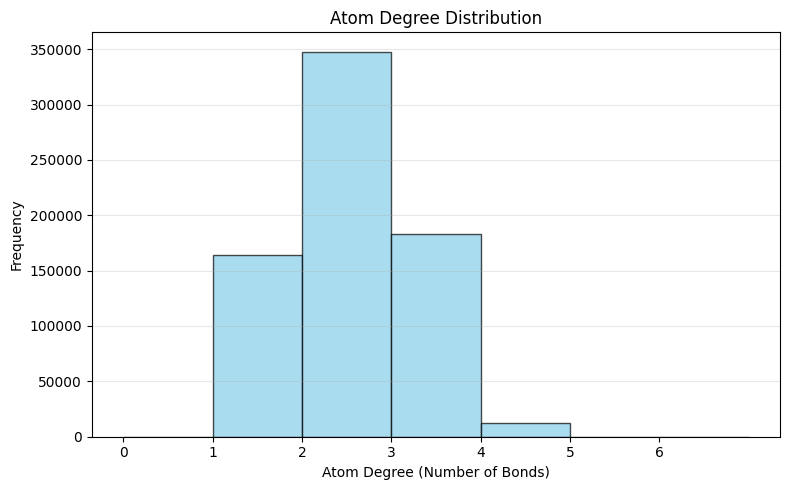

 Atom Degree Statistics:
  Total atoms analyzed: 707029
  Min degree: 0
  Max degree: 6
  Mean degree: 2.06
  Median degree: 2.00

  Degree frequency:
    Degree 0: 16 atoms (0.00%)
    Degree 1: 164,441 atoms (23.26%)
    Degree 2: 347,809 atoms (49.19%)
    Degree 3: 182,781 atoms (25.85%)
    Degree 4: 11,971 atoms (1.69%)
    Degree 5: 10 atoms (0.00%)
    Degree 6: 1 atoms (0.00%)


In [22]:
# Sample for faster analysis (use full data for final report)
sample_size = min(50000, len(df))
sample_smiles = df['smiles'].sample(sample_size, random_state=42).tolist()

# Collect atom degrees
degrees = []

for smi in sample_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for atom in mol.GetAtoms():
            degrees.append(atom.GetDegree())  # Number of bonded neighbors

# Plot degree distribution
plt.figure(figsize=(8, 5))
max_degree = max(degrees) if degrees else 0
plt.hist(degrees, bins=range(0, max_degree + 2), edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Atom Degree (Number of Bonds)')
plt.ylabel('Frequency')
plt.title('Atom Degree Distribution')
plt.xticks(range(0, max_degree + 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
degree_counts = Counter(degrees)
print(f" Atom Degree Statistics:")
print(f"  Total atoms analyzed: {len(degrees)}")
print(f"  Min degree: {min(degrees)}")
print(f"  Max degree: {max(degrees)}")
print(f"  Mean degree: {np.mean(degrees):.2f}")
print(f"  Median degree: {np.median(degrees):.2f}")
print(f"\n  Degree frequency:")
for deg in sorted(degree_counts.keys()):
    pct = degree_counts[deg] / len(degrees) * 100
    print(f"    Degree {deg}: {degree_counts[deg]:,} atoms ({pct:.2f}%)")

 Graph Size vs. HOMO-LUMO Gap Correlation:
  num_atoms ↔ target: -0.2578
  num_bonds ↔ target: -0.3104


C:\Users\js731\AppData\Local\Temp\ipykernel_21500\3103389617.py:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\js731\Downloads\GNN-HOMO-LUMO\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


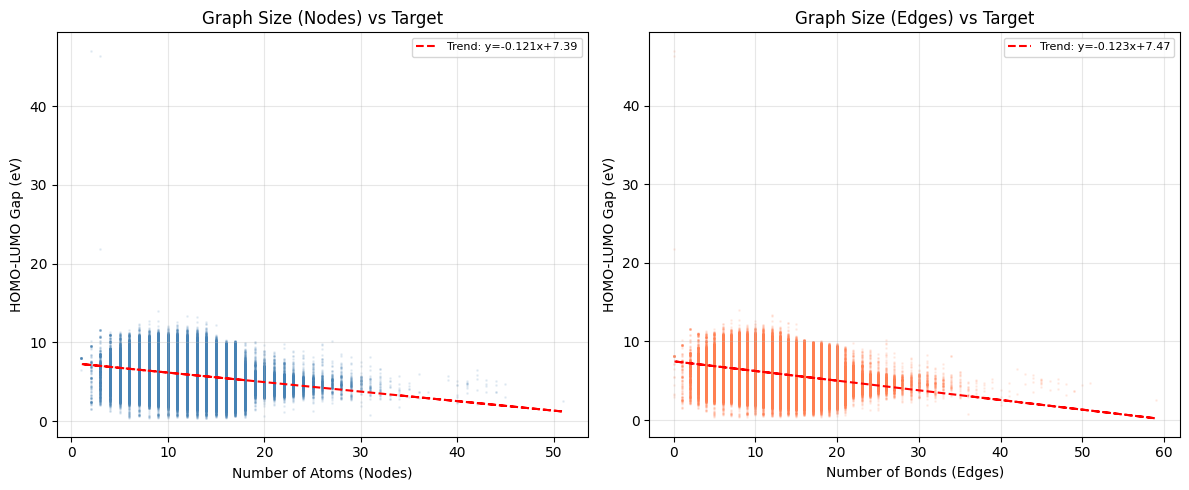


 Binned Analysis (by num_atoms):
              mean       std    count
atom_bin                             
(0, 10]   6.268725  1.371136   319923
(10, 15]  5.793156  1.172794  1924864
(15, 20]  5.342403  0.965142  1178323
(20, 30]  4.799962  1.022451     3145
(30, 60]  4.330148  1.097626      130


C:\Users\js731\AppData\Local\Temp\ipykernel_21500\3103389617.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df_with_target.groupby('atom_bin')['target'].agg(['mean', 'std', 'count'])


In [23]:
# Filter to samples with valid targets
df_with_target = df[df['target'].notna()].copy()

# Correlation analysis
print(f" Graph Size vs. HOMO-LUMO Gap Correlation:")
corr_atoms = df_with_target['num_atoms'].corr(df_with_target['target'])
corr_bonds = df_with_target['num_bonds'].corr(df_with_target['target'])

print(f"  num_atoms ↔ target: {corr_atoms:.4f}")
print(f"  num_bonds ↔ target: {corr_bonds:.4f}")

# Visualization
plt.figure(figsize=(12, 5))

# Atoms vs Target
plt.subplot(1, 2, 1)
plt.scatter(df_with_target['num_atoms'], df_with_target['target'], 
        alpha=0.1, s=1, color='steelblue')
plt.xlabel('Number of Atoms (Nodes)')
plt.ylabel('HOMO-LUMO Gap (eV)')
plt.title('Graph Size (Nodes) vs Target')
plt.grid(alpha=0.3)

# Add trend line
z = np.polyfit(df_with_target['num_atoms'], df_with_target['target'], 1)
p = np.poly1d(z)
plt.plot(df_with_target['num_atoms'], p(df_with_target['num_atoms']), 
        "r--", label=f"Trend: y={z[0]:.3f}x+{z[1]:.2f}")
plt.legend(fontsize=8)

# Bonds vs Target
plt.subplot(1, 2, 2)
plt.scatter(df_with_target['num_bonds'], df_with_target['target'], 
            alpha=0.1, s=1, color='coral')
plt.xlabel('Number of Bonds (Edges)')
plt.ylabel('HOMO-LUMO Gap (eV)')
plt.title('Graph Size (Edges) vs Target')
plt.grid(alpha=0.3)

# Add trend line
z = np.polyfit(df_with_target['num_bonds'], df_with_target['target'], 1)
p = np.poly1d(z)
plt.plot(df_with_target['num_bonds'], p(df_with_target['num_bonds']), 
        "r--", label=f"Trend: y={z[0]:.3f}x+{z[1]:.2f}")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Binned analysis for clearer trend
print(f"\n Binned Analysis (by num_atoms):")
df_with_target['atom_bin'] = pd.cut(df_with_target['num_atoms'], bins=[0, 10, 15, 20, 30, 60])
binned = df_with_target.groupby('atom_bin')['target'].agg(['mean', 'std', 'count'])
print(binned)

 GNN Architecture Guidance:
  Maximum atom degree observed: 6
  Recommended aggregation: Sum/Mean pooling (handles variable neighbors)
  If using attention: Ensure it scales to 6 neighbors


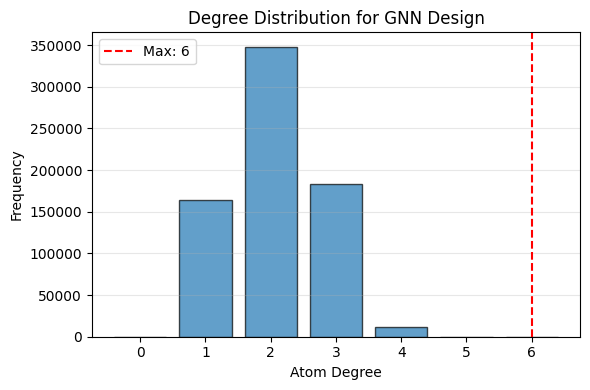

In [24]:
# Find global max degree (for architecture design)
max_degree_overall = 0
for smi in df['smiles'].sample(min(100000, len(df)), random_state=42):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for atom in mol.GetAtoms():
            max_degree_overall = max(max_degree_overall, atom.GetDegree())

print(f" GNN Architecture Guidance:")
print(f"  Maximum atom degree observed: {max_degree_overall}")
print(f"  Recommended aggregation: Sum/Mean pooling (handles variable neighbors)")
print(f"  If using attention: Ensure it scales to {max_degree_overall} neighbors")

# Degree distribution for message passing analysis
degree_dist = Counter()
for smi in df['smiles'].sample(min(50000, len(df)), random_state=42):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for atom in mol.GetAtoms():
            degree_dist[atom.GetDegree()] += 1

# Plot for architecture reference
plt.figure(figsize=(6, 4))
degrees, counts = zip(*sorted(degree_dist.items()))
plt.bar(degrees, counts, edgecolor='black', alpha=0.7)
plt.axvline(x=max_degree_overall, color='red', linestyle='--', label=f'Max: {max_degree_overall}')
plt.xlabel('Atom Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution for GNN Design')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

 Extracting Murcko scaffolds...
 Valid scaffolds: 50000/50000

 Scaffold Statistics:
  Total unique scaffolds: 13826
  Most common scaffold count: 7997
  Scaffolds with only 1 molecule: 11074
  Scaffolds with ≥10 molecules: 350


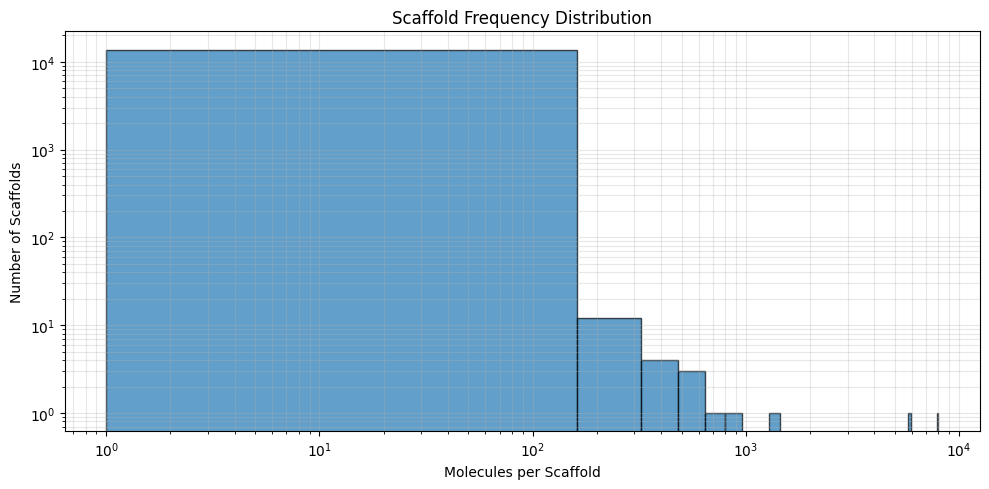


 Scaffold Split Feasibility:
  Scaffolds with ≥10 molecules: 350 (2.5%)
  Molecules in feasible scaffolds: 31428 (62.9%)
   Consider using random split or lowering min_scaffold_size


In [25]:
# Sample for faster analysis (use full data for final split)
sample_size = min(50000, len(df))
sample_df = df.sample(sample_size, random_state=42).copy()

def get_murcko_scaffold(smiles):
    """Extract Murcko scaffold from SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    if scaffold is None:
        return None
    return Chem.MolToSmiles(scaffold)

# Extract scaffolds
print(" Extracting Murcko scaffolds...")
sample_df['scaffold'] = sample_df['smiles'].apply(get_murcko_scaffold)

# Remove rows with invalid scaffolds
valid_scaffold_df = sample_df[sample_df['scaffold'].notna()].copy()
print(f" Valid scaffolds: {len(valid_scaffold_df)}/{len(sample_df)}")

# Analyze scaffold distribution
scaffold_counts = valid_scaffold_df['scaffold'].value_counts()
print(f"\n Scaffold Statistics:")
print(f"  Total unique scaffolds: {len(scaffold_counts)}")
print(f"  Most common scaffold count: {scaffold_counts.iloc[0]}")
print(f"  Scaffolds with only 1 molecule: {(scaffold_counts == 1).sum()}")
print(f"  Scaffolds with ≥10 molecules: {(scaffold_counts >= 10).sum()}")

# Plot scaffold frequency distribution (log scale)
plt.figure(figsize=(10, 5))
plt.hist(scaffold_counts.values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Molecules per Scaffold')
plt.ylabel('Number of Scaffolds')
plt.title('Scaffold Frequency Distribution')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Check if scaffold split is feasible
min_scaffold_size = 10  # Minimum molecules per scaffold for meaningful split
feasible_scaffolds = scaffold_counts[scaffold_counts >= min_scaffold_size]
feasible_ratio = len(feasible_scaffolds) / len(scaffold_counts) * 100

print(f"\n Scaffold Split Feasibility:")
print(f"  Scaffolds with ≥{min_scaffold_size} molecules: {len(feasible_scaffolds)} ({feasible_ratio:.1f}%)")
print(f"  Molecules in feasible scaffolds: {feasible_scaffolds.sum()} ({feasible_scaffolds.sum()/len(valid_scaffold_df)*100:.1f}%)")

if feasible_ratio > 30:
    print("   Scaffold split is FEASIBLE for evaluation")
else:
    print("   Consider using random split or lowering min_scaffold_size")

 Target Distribution for Classification:
  Samples: 3423877
  Range: 0.376 - 9.997 eV
  Mean: 5.678 eV, Std: 1.154 eV

 Equal-Width Bins (5 classes):
  0.4-2.3 eV: 4,855 (0.1%)
  2.3-4.2 eV: 284,293 (8.3%)
  4.2-6.1 eV: 2,090,708 (61.1%)
  6.1-8.1 eV: 945,462 (27.6%)
  8.1-10.0 eV: 98,559 (2.9%)

 Equal-Frequency Bins (5 classes):
  Q1: 686,128 (20.0%)
  Q2: 683,866 (20.0%)
  Q3: 685,358 (20.0%)
  Q4: 683,993 (20.0%)
  Q5: 684,532 (20.0%)


C:\Users\js731\AppData\Local\Temp\ipykernel_21500\2960719032.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class_equal', data=clean_df, ax=axes[0], palette='Blues_d')
C:\Users\js731\AppData\Local\Temp\ipykernel_21500\2960719032.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class_quantile', data=clean_df, ax=axes[1], palette='Greens_d')


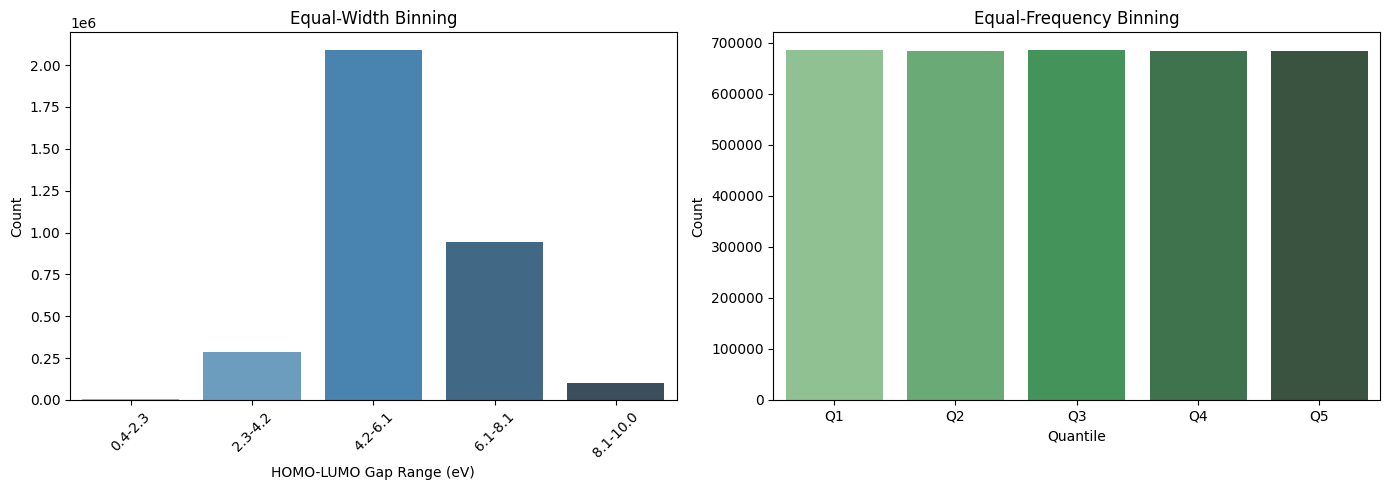


  Class Imbalance Ratio (max/min):
  Equal-width bins: 430.63x
  Equal-frequency bins: 1.00x
  → Lower is better; <3x is generally acceptable


In [26]:
# Use clean data with valid targets
clean_df = df[df['target'].notna() & (df['target'] <= 10)].copy()
targets = clean_df['target'].values

print(f" Target Distribution for Classification:")
print(f"  Samples: {len(targets)}")
print(f"  Range: {targets.min():.3f} - {targets.max():.3f} eV")
print(f"  Mean: {targets.mean():.3f} eV, Std: {targets.std():.3f} eV")

# Strategy 1: Equal-width bins
n_bins = 5
bin_edges_equal = np.linspace(targets.min(), targets.max(), n_bins + 1)
labels_equal = [f"{bin_edges_equal[i]:.1f}-{bin_edges_equal[i+1]:.1f}" for i in range(n_bins)]
clean_df['class_equal'] = pd.cut(clean_df['target'], bins=bin_edges_equal, labels=labels_equal, include_lowest=True)

print(f"\n Equal-Width Bins ({n_bins} classes):")
class_counts_equal = clean_df['class_equal'].value_counts().sort_index()
for label, count in class_counts_equal.items():
    pct = count / len(clean_df) * 100
    print(f"  {label} eV: {count:,} ({pct:.1f}%)")

# Strategy 2: Equal-frequency (quantile) bins
clean_df['class_quantile'] = pd.qcut(clean_df['target'], q=n_bins, labels=[f"Q{i+1}" for i in range(n_bins)], duplicates='drop')

print(f"\n Equal-Frequency Bins ({n_bins} classes):")
class_counts_quantile = clean_df['class_quantile'].value_counts().sort_index()
for label, count in class_counts_quantile.items():
    pct = count / len(clean_df) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

# Visualize both strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Equal-width
sns.countplot(x='class_equal', data=clean_df, ax=axes[0], palette='Blues_d')
axes[0].set_xlabel('HOMO-LUMO Gap Range (eV)')
axes[0].set_ylabel('Count')
axes[0].set_title('Equal-Width Binning')
axes[0].tick_params(axis='x', rotation=45)

# Equal-frequency
sns.countplot(x='class_quantile', data=clean_df, ax=axes[1], palette='Greens_d')
axes[1].set_xlabel('Quantile')
axes[1].set_ylabel('Count')
axes[1].set_title('Equal-Frequency Binning')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Calculate imbalance metrics
def calculate_imbalance(class_counts):
    """Calculate class imbalance ratio."""
    max_count = class_counts.max()
    min_count = class_counts.min()
    return max_count / min_count if min_count > 0 else float('inf')

imbalance_equal = calculate_imbalance(class_counts_equal.values)
imbalance_quantile = calculate_imbalance(class_counts_quantile.values)

print(f"\n  Class Imbalance Ratio (max/min):")
print(f"  Equal-width bins: {imbalance_equal:.2f}x")
print(f"  Equal-frequency bins: {imbalance_quantile:.2f}x")
print(f"  → Lower is better; <3x is generally acceptable")

In [27]:
def get_atom_features(atom):
    """
    Extract 9-dimensional atom features (PCQM4Mv2 standard).
    """
    features = []
    
    # 1. Atomic number (one-hot encoded for common elements)
    atomic_num = atom.GetAtomicNum()
    features.append(atomic_num)
    
    # 2. Number of implicit Hs
    features.append(atom.GetTotalNumHs())
    
    # 3. Formal charge
    features.append(atom.GetFormalCharge())
    
    # 4. Radical electrons
    features.append(atom.GetNumRadicalElectrons())
    
    # 5. Hybridization (one-hot: SP, SP2, SP3, etc.)
    hybridization = atom.GetHybridization()
    hybrid_dict = {
        Chem.rdchem.HybridizationType.SP: 0,
        Chem.rdchem.HybridizationType.SP2: 1,
        Chem.rdchem.HybridizationType.SP3: 2,
        Chem.rdchem.HybridizationType.SP3D: 3,
        Chem.rdchem.HybridizationType.SP3D2: 4,
    }
    features.append(hybrid_dict.get(hybridization, 5))
    
    # 6. Is in aromatic ring
    features.append(1 if atom.GetIsAromatic() else 0)
    
    # 7. Is in ring
    features.append(1 if atom.IsInRing() else 0)
    
    # 8. Chirality (one-hot)
    chirality = atom.GetChiralTag()
    chirality_dict = {
        Chem.rdchem.ChiralType.CHI_UNSPECIFIED: 0,
        Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW: 1,
        Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW: 2,
        Chem.rdchem.ChiralType.CHI_OTHER: 3,
    }
    features.append(chirality_dict.get(chirality, 0))
    
    # 9. Heavy atom degree (number of heavy atom neighbors)
    features.append(atom.GetDegree())
    
    return np.array(features, dtype=np.float32)

# Test on sample molecules
sample_smiles = df['smiles'].sample(5, random_state=42).tolist()

print(" Node Feature Dimensionality Check:")
print("="*60)
for i, smi in enumerate(sample_smiles):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        # Get features for first atom
        first_atom_features = get_atom_features(mol.GetAtomWithIdx(0))
        print(f"Molecule {i+1}: {smi[:40]}...")
        print(f"  Num atoms: {mol.GetNumAtoms()}")
        print(f"  Node feature shape: {first_atom_features.shape}")
        print(f"  Feature values: {first_atom_features}")
        print()

 Node Feature Dimensionality Check:
Molecule 1: CCOC(CN(C1CC1)C)OCC...
  Num atoms: 13
  Node feature shape: (9,)
  Feature values: [6. 3. 0. 0. 2. 0. 0. 0. 1.]

Molecule 2: CN(C[C@@H]1[C@H](N=C1O)C(=O)O)P...
  Num atoms: 12
  Node feature shape: (9,)
  Feature values: [6. 3. 0. 0. 2. 0. 0. 0. 1.]

Molecule 3: O=N(=O)[C@H](C/N=C(\c1cccnc1)/O)O...
  Num atoms: 15
  Node feature shape: (9,)
  Feature values: [ 8.  0. -1.  0.  1.  0.  0.  0.  1.]

Molecule 4: CC(c1nc2c([nH]1)cccc2)C...
  Num atoms: 12
  Node feature shape: (9,)
  Feature values: [6. 3. 0. 0. 2. 0. 0. 0. 1.]

Molecule 5: Nc1cccc(c1)/N=C(/OCc1ccco1)\O...
  Num atoms: 17
  Node feature shape: (9,)
  Feature values: [7. 2. 0. 0. 1. 0. 0. 0. 1.]



 Edge Feature Distribution:
Total bonds analyzed: 145259

Bond Type Distribution:
  SINGLE: 90,766 (62.49%)
  DOUBLE: 9,587 (6.60%)
  TRIPLE: 790 (0.54%)
  AROMATIC: 44,116 (30.37%)
  OTHER: 0 (0.00%)

Conjugated bonds: 66,873 (46.04%)
Bonds with stereochemistry: 1,563 (1.08%)


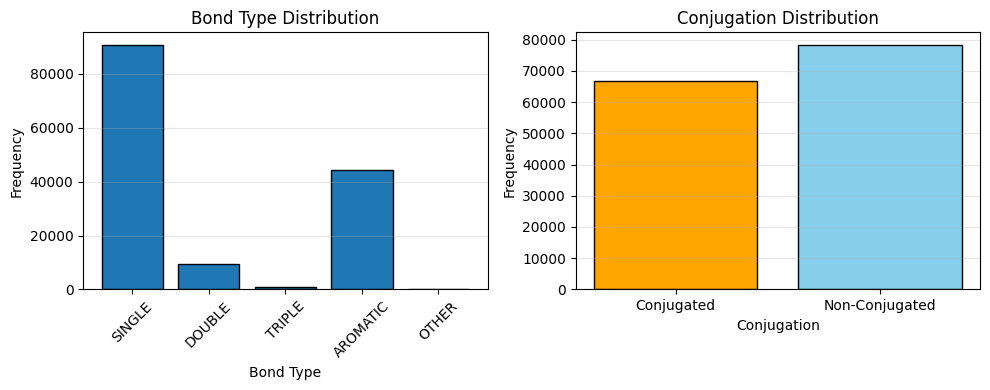

In [28]:
def get_bond_features(bond):
    """
    Extract 3-dimensional bond features (PCQM4Mv2 standard).
    """
    features = []
    
    # 1. Bond type (one-hot: SINGLE, DOUBLE, TRIPLE, AROMATIC)
    bond_type = bond.GetBondType()
    bond_dict = {
        Chem.rdchem.BondType.SINGLE: 0,
        Chem.rdchem.BondType.DOUBLE: 1,
        Chem.rdchem.BondType.TRIPLE: 2,
        Chem.rdchem.BondType.AROMATIC: 3,
    }
    features.append(bond_dict.get(bond_type, 4))
    
    # 2. Is conjugated
    features.append(1 if bond.GetIsConjugated() else 0)
    
    # 3. Bond stereochemistry (one-hot)
    stereo = bond.GetStereo()
    stereo_dict = {
        Chem.rdchem.BondStereo.STEREONONE: 0,
        Chem.rdchem.BondStereo.STEREOE: 1,
        Chem.rdchem.BondStereo.STEREOZ: 2,
        Chem.rdchem.BondStereo.STEREOCIS: 3,
        Chem.rdchem.BondStereo.STEREOTRANS: 4,
    }
    features.append(stereo_dict.get(stereo, 0))
    
    return np.array(features, dtype=np.float32)

# Analyze bond feature distribution across dataset
print(" Edge Feature Distribution:")


bond_type_counter = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}  # SINGLE, DOUBLE, TRIPLE, AROMATIC, OTHER
conjugated_count = 0
stereo_count = 0
total_bonds = 0

sample_smiles = df['smiles'].sample(10000, random_state=42).tolist()

for smi in sample_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for bond in mol.GetBonds():
            features = get_bond_features(bond)
            bond_type_counter[int(features[0])] += 1
            conjugated_count += int(features[1])
            stereo_count += 1 if features[2] > 0 else 0
            total_bonds += 1

print(f"Total bonds analyzed: {total_bonds}")
print(f"\nBond Type Distribution:")
bond_type_names = ['SINGLE', 'DOUBLE', 'TRIPLE', 'AROMATIC', 'OTHER']
for i, (type_idx, count) in enumerate(bond_type_counter.items()):
    pct = count / total_bonds * 100
    print(f"  {bond_type_names[i]}: {count:,} ({pct:.2f}%)")

print(f"\nConjugated bonds: {conjugated_count:,} ({conjugated_count/total_bonds*100:.2f}%)")
print(f"Bonds with stereochemistry: {stereo_count:,} ({stereo_count/total_bonds*100:.2f}%)")



plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(bond_type_names, list(bond_type_counter.values()), edgecolor='black')
plt.xlabel('Bond Type')
plt.ylabel('Frequency')
plt.title('Bond Type Distribution')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(['Conjugated', 'Non-Conjugated'], 
        [conjugated_count, total_bonds - conjugated_count], 
        edgecolor='black', color=['orange', 'skyblue'])
plt.xlabel('Conjugation')
plt.ylabel('Frequency')
plt.title('Conjugation Distribution')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
def smiles_to_pyg_graph(smiles, include_target=None):
    """
    Convert SMILES to PyTorch Geometric Data object.
    
    Args:
        smiles: SMILES string
        include_target: Optional target value (HOMO-LUMO gap)
    
    Returns:
        PyG Data object with x, edge_index, edge_attr, y
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Node features
    node_features = []
    for atom in mol.GetAtoms():
        node_features.append(get_atom_features(atom))
    x = torch.tensor(np.array(node_features), dtype=torch.float)
    
    # Edge index and features
    edge_indices = []
    edge_features = []
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_feat = get_bond_features(bond)
        
        # Add both directions (undirected graph)
        edge_indices.append([i, j])
        edge_indices.append([j, i])
        edge_features.append(edge_feat)
        edge_features.append(edge_feat)
    
    if len(edge_indices) > 0:
        edge_index = torch.tensor(np.array(edge_indices).T, dtype=torch.long)
        edge_attr = torch.tensor(np.array(edge_features), dtype=torch.float)
    else:
        # Molecule with no bonds (single atom)
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 3), dtype=torch.float)
    
    # Target
    y = torch.tensor([include_target], dtype=torch.float) if include_target is not None else None
    
    # Create PyG Data object
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data.num_atoms = mol.GetNumAtoms()
    data.num_bonds = mol.GetNumBonds()
    data.smiles = smiles
    
    return data

# for Test the function
test_smiles = df['smiles'].iloc[0]
test_target = df['target'].iloc[0] if 'target' in df.columns else None

pyg_data = smiles_to_pyg_graph(test_smiles, include_target=test_target)

print("\n PyG Data Object Test:")
print("="*60)
print(f"SMILES: {test_smiles[:50]}...")
print(f"Node features (x): {pyg_data.x.shape}")  #  [num_atoms, 9]
print(f"Edge index: {pyg_data.edge_index.shape}")  #  [2, 2*num_bonds]
print(f"Edge features (edge_attr): {pyg_data.edge_attr.shape}")  #  [2*num_bonds, 3]
print(f"Target (y): {pyg_data.y}")
print(f"Num atoms: {pyg_data.num_atoms}")
print(f"Num bonds: {pyg_data.num_bonds}")


 PyG Data Object Test:
SMILES: O=C1[N]c2ccncc2[CH][C@@H]1c1ccc(cc1)C...
Node features (x): torch.Size([18, 9])
Edge index: torch.Size([2, 40])
Edge features (edge_attr): torch.Size([40, 3])
Target (y): tensor([3.0477])
Num atoms: 18
Num bonds: 20
